# Reinforcement Learning for Multicast Rate Maximization

### Problem Formulation

We have a directed graph $G(V,E)$, and a set of sink nodes $A \subseteq V$. We want to select at most $k$ source nodes from $V$ to maximize the multi-source multicast rate $\rho_{ms}(S,A)$:

$$
\max_{S \subseteq V,\,|S|\le k} \rho_{ms}(S,A)
$$

### Reinforcement Learning Formulation (MDP)

We model the problem as a Markov Decision Process (MDP):

- **State**: Current set of selected sources $S_t \subseteq V$.
- **Action**: Choosing a node $v \in V\setminus S_t$ as the next source.
- **Reward**: At the end of selection (after $k$ nodes), reward is the multicast rate:
$$
R(S) = \rho_{ms}(S,A)
$$

We train an RL agent with a policy network using the REINFORCE method to maximize the expected multicast rate.


In [1]:
# Install required libraries (if needed)
# !pip install torch igraph numpy matplotlib

# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


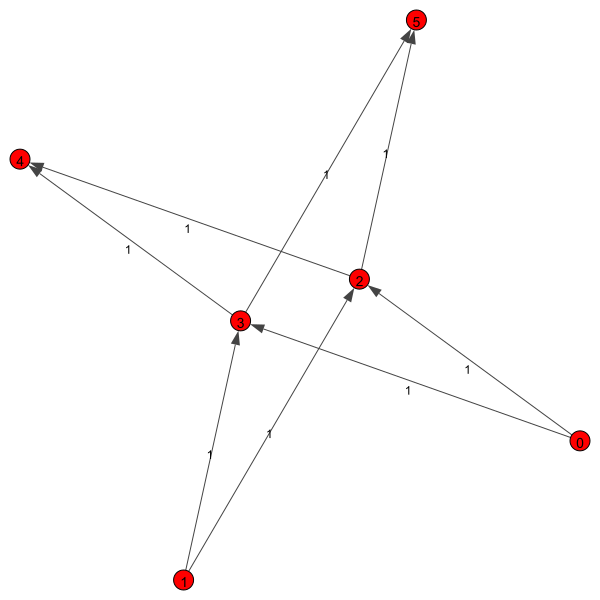

In [2]:
def create_butterfly_graph():
    g = ig.Graph(directed=True)
    g.add_vertices(6)
    edges = [(0,2),(0,3),(1,2),(1,3),(2,4),(3,5),(2,5),(3,4)]
    g.add_edges(edges)
    g.es["capacity"] = [1]*len(edges)
    return g

graph = create_butterfly_graph()

# Draw the graph
ig.plot(graph, layout="kk", vertex_label=range(graph.vcount()), edge_label=graph.es["capacity"])


In [68]:
import math

def rate_ss(graph, S, A):
    if A == set(): 
        return math.inf
    elif S.issubset(A): 
        return float(0)
    
    new_node = len(graph.vs)
    flows = []
    
    if len(S) == 1:
        s = list(S)[0]
        for j in A:            
            min_cut_value = graph.mincut(s, j, capacity=graph.es["capacity"]).value
            flows.append(min_cut_value)
        return min(flows)
    
    for j in A:
        mapping_vector = [i if i not in S - {j} else new_node for i in range(new_node)]
        contracted_graph = graph.copy()
        contracted_graph.contract_vertices(mapping_vector, combine_attrs={"capacity": sum})
        min_cut_value = contracted_graph.mincut(new_node, j, capacity=contracted_graph.es["capacity"]).value
        flows.append(min_cut_value)
            
    return min(flows)

In [69]:
S_example = {0, 1}
A_example = {4, 5}
rate_ss(graph, S_example, A_example)  # should return 2 for butterfly network

2.0

In [70]:
class PolicyNet(nn.Module):
    def __init__(self, num_nodes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_nodes, 64),
            nn.ReLU(),
            nn.Linear(64, num_nodes),
        )

    def forward(self, state):
        logits = self.model(state)
        logits[state.bool()] = -1e9  # mask selected nodes
        return torch.softmax(logits, dim=-1)

policy = PolicyNet(num_nodes=graph.vcount()).to(device)

In [71]:
def train_rl_agent(graph, policy, A, k, episodes=500, lr=0.01):
    optimizer = optim.Adam(policy.parameters(), lr=lr)
    sink_mask = torch.zeros(graph.vcount(), device=device)
    sink_mask[list(A)] = 1  # explicitly mask sink nodes

    for episode in range(episodes):
        S = set()
        log_probs = []
        state = torch.zeros(graph.vcount(), device=device)

        for _ in range(k):
            mask = state + sink_mask  # combine state and sink mask
            probs = policy(mask)
            dist = torch.distributions.Categorical(probs)
            action = dist.sample()
            log_probs.append(dist.log_prob(action))
            S.add(action.item())
            state[action.item()] = 1

        reward = rate_ss(graph, S, A)
        loss = -torch.stack(log_probs).sum() * reward

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (episode+1) % 50 == 0:
            print(f"Episode {episode+1}/{episodes}, Reward: {reward}")

# Run training again with corrected code
train_rl_agent(graph, policy, A={4,5}, k=2)

Episode 50/500, Reward: 2.0
Episode 100/500, Reward: 2.0
Episode 150/500, Reward: 2.0
Episode 200/500, Reward: 2.0
Episode 250/500, Reward: 2.0
Episode 300/500, Reward: 2.0
Episode 350/500, Reward: 2.0
Episode 400/500, Reward: 2.0
Episode 450/500, Reward: 2.0
Episode 500/500, Reward: 2.0


In [72]:
def evaluate_policy(graph, policy, A, k):
    policy.eval()
    with torch.no_grad():
        S = set()
        state = torch.zeros(graph.vcount(), device=device)

        for _ in range(k):
            mask = state.clone()
            mask[list(A)] = 1  # ensure sinks are masked
            probs = policy(mask)
            action = torch.argmax(probs).item()
            S.add(action)
            state[action] = 1

        final_rate = rate_ss(graph, S, A)
        print(f"Selected Sources: {S}, Multicast Rate: {final_rate}")

evaluate_policy(graph, policy, A={4,5}, k=2)

Selected Sources: {2, 3}, Multicast Rate: 2.0


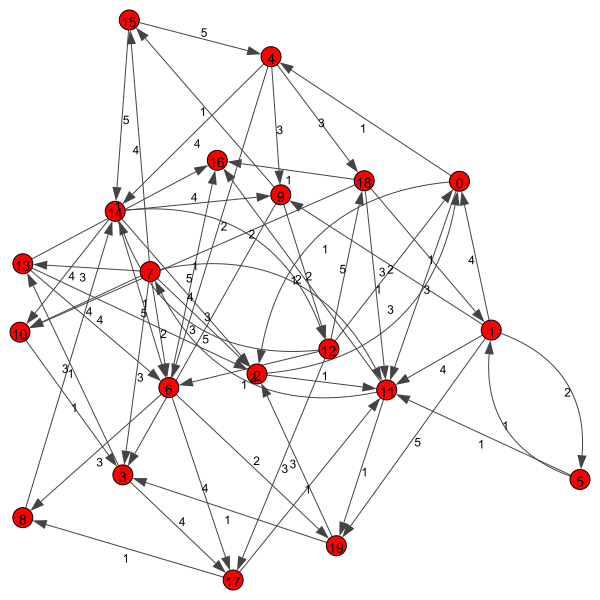

In [73]:
def create_large_graph(num_nodes=20, num_edges=60, capacity_range=(1,5), seed=42):
    np.random.seed(seed)
    g = ig.Graph(directed=True)
    g.add_vertices(num_nodes)
    
    edges = set()
    while len(edges) < num_edges:
        u, v = np.random.randint(0, num_nodes, 2)
        if u != v:
            edges.add((u, v))
    
    g.add_edges(list(edges))
    g.es["capacity"] = np.random.randint(capacity_range[0], capacity_range[1]+1, len(edges)).tolist()
    return g

graph_large = create_large_graph()

# Visualize the graph (optional)
layout = graph_large.layout("kk")
ig.plot(graph_large, layout=layout, vertex_label=range(graph_large.vcount()), edge_label=graph_large.es["capacity"])

In [74]:
num_sinks = 2
A_large = set(np.random.choice(graph_large.vcount(), num_sinks, replace=False))
print("Sink nodes A:", A_large)


Sink nodes A: {11, 4}


In [75]:
policy_large = PolicyNet(graph_large.vcount()).to(device)

# Example: Train the agent to pick 3 source nodes
def train_rl_agent(graph, policy, A, k, episodes=5000, lr=0.01, entropy_beta=0.01):
    optimizer = optim.Adam(policy.parameters(), lr=lr)
    sink_mask = torch.zeros(graph.vcount(), device=device)
    sink_mask[list(A)] = 1

    baseline = 0.0
    gamma = 0.9

    for episode in range(episodes):
        S = set()
        log_probs = []
        entropies = []
        state = torch.zeros(graph.vcount(), device=device)

        for _ in range(k):
            mask = state + sink_mask
            probs = policy(mask)
            dist = torch.distributions.Categorical(probs)
            action = dist.sample()
            log_probs.append(dist.log_prob(action))
            entropies.append(dist.entropy())
            S.add(action.item())
            state[action.item()] = 1

        reward = rate_ss(graph, S, A)

        # Update baseline
        baseline = gamma * baseline + (1 - gamma) * reward

        # Compute loss with baseline and entropy regularization
        loss = -torch.stack(log_probs).sum() * (reward - baseline) - entropy_beta * torch.stack(entropies).sum()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (episode+1) % 100 == 0:
            print(f"Episode {episode+1}/{episodes}, Reward: {reward:.2f}, Baseline: {baseline:.2f}")

# Retrain with improved RL loop
train_rl_agent(graph_large, policy_large, A_large, k=3, episodes=5000)

evaluate_policy(graph_large, policy_large, A_large, k=3)

Episode 100/5000, Reward: 6.00, Baseline: 6.00
Episode 200/5000, Reward: 6.00, Baseline: 6.00
Episode 300/5000, Reward: 6.00, Baseline: 6.00
Episode 400/5000, Reward: 6.00, Baseline: 6.00
Episode 500/5000, Reward: 6.00, Baseline: 6.00
Episode 600/5000, Reward: 6.00, Baseline: 6.00
Episode 700/5000, Reward: 6.00, Baseline: 5.99
Episode 800/5000, Reward: 6.00, Baseline: 6.00
Episode 900/5000, Reward: 6.00, Baseline: 6.00
Episode 1000/5000, Reward: 6.00, Baseline: 6.00
Episode 1100/5000, Reward: 6.00, Baseline: 6.00
Episode 1200/5000, Reward: 6.00, Baseline: 6.00
Episode 1300/5000, Reward: 6.00, Baseline: 6.00
Episode 1400/5000, Reward: 6.00, Baseline: 6.00
Episode 1500/5000, Reward: 6.00, Baseline: 6.00
Episode 1600/5000, Reward: 6.00, Baseline: 6.00
Episode 1700/5000, Reward: 6.00, Baseline: 6.00
Episode 1800/5000, Reward: 6.00, Baseline: 6.00
Episode 1900/5000, Reward: 6.00, Baseline: 6.00
Episode 2000/5000, Reward: 6.00, Baseline: 6.00
Episode 2100/5000, Reward: 6.00, Baseline: 6.00
E

In [76]:
# Greedy selection for comparison
def greedy_selection(graph, A, k):
    V = set(range(graph.vcount())) - A
    S = set()
    for _ in range(k):
        best_node = None
        best_rate = -1
        for node in V - S:
            candidate_S = S | {node}
            rate = rate_ss(graph, candidate_S, A)
            if rate > best_rate:
                best_rate = rate
                best_node = node
        S.add(best_node)
    return S, rate_ss(graph, S, A)

S_greedy, rate_greedy = greedy_selection(graph_large, A_large, k=3)
print(f"Greedy Selected Sources: {S_greedy}, Multicast Rate: {rate_greedy}")

Greedy Selected Sources: {0, 1, 7}, Multicast Rate: 6.0


In [77]:
graph_large = create_large_graph(num_nodes=5000, num_edges=25000, capacity_range=(1,10), seed=42)
print(f"Graph has {graph_large.vcount()} nodes and {graph_large.ecount()} edges.")

Graph has 5000 nodes and 25000 edges.


In [78]:
num_sinks = 100
A_large = set(np.random.choice(graph_large.vcount(), num_sinks, replace=False))
print("Sink nodes (A):", A_large)

Sink nodes (A): {3077, 1556, 1559, 540, 30, 2078, 545, 4136, 566, 2104, 3650, 1095, 76, 4691, 3667, 1119, 4195, 4196, 616, 1129, 4206, 4729, 2175, 133, 1162, 1682, 4244, 2708, 3222, 150, 3224, 162, 4265, 1197, 4784, 1713, 3762, 1716, 4790, 4796, 197, 4309, 1238, 2275, 744, 1770, 1263, 1776, 3833, 1275, 254, 1279, 4863, 2305, 4866, 2823, 781, 4880, 788, 2326, 1822, 287, 2341, 1832, 819, 4408, 1848, 2884, 3934, 3937, 2405, 1894, 1408, 911, 2963, 1444, 2983, 4008, 429, 1974, 4025, 442, 4032, 3012, 460, 4560, 4561, 4565, 4567, 2521, 4571, 2529, 4578, 2531, 3045, 1510, 4074, 2542, 1021, 2047}


In [79]:
policy_large = PolicyNet(graph_large.vcount()).to(device)
# Parameters
k = 5  # selecting 5 source nodes
episodes = 3000
lr = 0.01
entropy_beta = 0.02

# Train RL agent on large graph
train_rl_agent(graph_large, policy_large, A_large, k=k, episodes=episodes, lr=lr, entropy_beta=entropy_beta)

Episode 100/3000, Reward: 0.00, Baseline: 0.00
Episode 200/3000, Reward: 0.00, Baseline: 0.00
Episode 300/3000, Reward: 0.00, Baseline: 0.00
Episode 400/3000, Reward: 0.00, Baseline: 0.00
Episode 500/3000, Reward: 0.00, Baseline: 0.00
Episode 600/3000, Reward: 0.00, Baseline: 0.00
Episode 700/3000, Reward: 0.00, Baseline: 0.00
Episode 800/3000, Reward: 0.00, Baseline: 0.00
Episode 900/3000, Reward: 0.00, Baseline: 0.00
Episode 1000/3000, Reward: 0.00, Baseline: 0.00
Episode 1100/3000, Reward: 0.00, Baseline: 0.00
Episode 1200/3000, Reward: 0.00, Baseline: 0.00
Episode 1300/3000, Reward: 0.00, Baseline: 0.00
Episode 1400/3000, Reward: 0.00, Baseline: 0.00
Episode 1500/3000, Reward: 0.00, Baseline: 0.00
Episode 1600/3000, Reward: 0.00, Baseline: 0.00
Episode 1700/3000, Reward: 0.00, Baseline: 0.00
Episode 1800/3000, Reward: 0.00, Baseline: 0.00
Episode 1900/3000, Reward: 0.00, Baseline: 0.00
Episode 2000/3000, Reward: 0.00, Baseline: 0.00
Episode 2100/3000, Reward: 0.00, Baseline: 0.00
E

In [80]:
evaluate_policy(graph_large, policy_large, A_large, k=k)

Selected Sources: {904, 3081, 2930, 787, 55}, Multicast Rate: 0.0


In [82]:
S_greedy, rate_greedy = greedy_selection(graph_large, A_large, k=k)
print(f"Greedy Selected Sources: {S_greedy}, Multicast Rate: {rate_greedy}")

KeyboardInterrupt: 